# Convolutional Neural Network (CNN)

demonstrates training a simple [Convolutional Neural Network](https://developers.google.com/machine-learning/glossary/#convolutional_neural_network) (CNN) to classify [CIFAR images](https://www.cs.toronto.edu/~kriz/cifar.html). Because this tutorial uses the [Keras Sequential API](https://www.tensorflow.org/guide/keras/overview), creating and training your model will take just a few lines of code.

A. Pengertian CNN
Convolutional Neural Network (CNN) adalah salah satu jenis arsitektur deep
learning yang dirancang untuk memproses data citra dua dimensi. CNN mampu
mengenali pola visual seperti tepi, warna, tekstur, hingga bentuk objek secara
otomatis melalui beberapa lapisan pembelajaran. CNN banyak digunakan dalam
image classification, object detection, face recognition, dan berbagai aplikasi
computer vision karena kemampuannya mengekstraksi fitur secara efektif tanpa
memerlukan ekstraksi fitur manual.

B. Cara Kerja CNN
Cara kerja CNN dimulai dari proses ekstraksi fitur menggunakan lapisan
convolution yang mendeteksi pola-pola dasar pada gambar. Hasil ekstraksi ini
kemudian diperkecil melalui pooling untuk mengurangi dimensi data sekaligus
mempertahankan informasi penting. Setelah melewati beberapa lapisan ini, data
diubah menjadi bentuk vektor dan diproses oleh fully connected layer untuk
melakukan klasifikasi. Selama pelatihan, CNN menyesuaikan bobot filter agar
menghasilkan prediksi yang semakin akurat.

C. Komponen CNN
    1. Feature Learning
        a. Convolution Layer + ReLU
            Lapisan convolution berfungsi untuk mengekstraksi fitur dari gambar
            menggunakan filter (kernel) yang bergerak ke seluruh area citra. Filter ini
            mendeteksi pola–pola dasar seperti garis, sudut, warna, atau tekstur.
            Setelah convolution, digunakan fungsi aktivasi ReLU (Rectified Linear
            Unit) untuk mengubah nilai negatif menjadi 0 dan mempertahankan nilai
            positif. ReLU membantu model belajar lebih cepat serta menambahkan
            sifat non-linear pada proses ekstraksi fitur.
        b. Pooling Layer (Max Pooling dan Average Pooling)
            Pooling digunakan untuk mengurangi dimensi fitur map sehingga proses
            komputasi lebih efisien.
● Max Pooling mengambil nilai maksimum pada setiap area kecil
(misalnya 2×2).
● Average Pooling mengambil nilai rata-rata pada area tersebut.
Keduanya membantu mempertahankan informasi penting sambil
mengurangi risiko overfitting.

### Import TensorFlow

In [7]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

#Mengunduh dan menyiapkan dataset CIFAR10

Dataset CIFAR10 berisi 60.000 gambar berwarna yang terbagi ke dalam 10 kelas, dengan 6.000 gambar untuk setiap kelas. Dataset ini dipisahkan menjadi 50.000 gambar untuk pelatihan dan 10.000 gambar untuk pengujian. Setiap kelas bersifat saling eksklusif dan tidak ada tumpang tindih di antara kelas-kelas tersebut.

In [8]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Resize images from 32x32 to 64x64
train_images = tf.image.resize(train_images, (64, 64))
test_images = tf.image.resize(test_images, (64, 64))

# Normalize pixel values (0 - 1)
train_images = train_images / 255.0
test_images = test_images / 255.0

# Class names
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

###Memverifikasi data

Untuk memastikan bahwa dataset terlihat benar, mari tampilkan 25 gambar pertama dari data pelatihan dan menampilkan nama kelas di bawah setiap gambar:

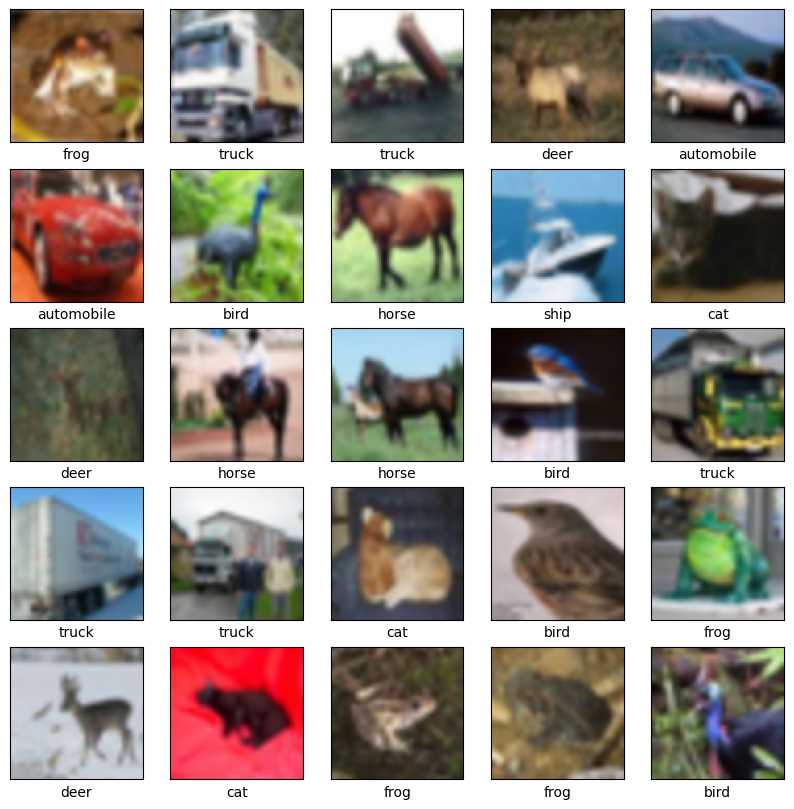

In [9]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

### Create the convolutional base

The 6 lines of code below define the convolutional base using a common pattern: a stack of [Conv2D](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv2D) and [MaxPooling2D](https://www.tensorflow.org/api_docs/python/tf/keras/layers/MaxPool2D) layers.

Sebagai input, sebuah CNN menerima tensor dengan bentuk (image_height, image_width, color_channels), mengabaikan ukuran batch. Jika kamu masih baru dengan dimensi ini, color_channels mengacu pada tiga komponen warna (R, G, B). Pada dataset CIFAR-10 standar, setiap gambar memiliki bentuk (32, 32, 3), dan biasanya kamu mengonfigurasi CNN untuk memproses format ini dengan memberikan argumen input_shape pada layer pertama.

Namun, dalam eksperimen ini gambar diubah ukurannya menjadi (64, 64, 3) untuk melihat bagaimana model berperilaku dengan resolusi input yang lebih tinggi. Peningkatan ukuran gambar memungkinkan CNN menangkap lebih banyak detail spasial dan fitur yang lebih kaya, yang mungkin meningkatkan akurasi — meskipun hal ini juga meningkatkan biaya komputasi. Dengan mengatur:

In [15]:
# Membuat model Sequential (model berlapis-lapis linear)
model = models.Sequential([

    # === BLOCK 1 ===
    # Layer konvolusi pertama: 32 filter, kernel 3x3, aktivasi ReLU
    # input_shape = (64, 64, 3) → ukuran gambar 64x64 dengan 3 channel (RGB)
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    
    # Batch Normalization membantu menstabilkan training dan mempercepat konvergensi
    layers.BatchNormalization(),
    
    # MaxPooling mengurangi ukuran spatial (mengambil nilai maksimum dari window 2x2)
    layers.MaxPooling2D((2,2)),


    # === BLOCK 2 ===
    # Konvolusi ke-2: 64 filter untuk mengekstrak fitur lebih dalam
    layers.Conv2D(64, (3,3), activation='relu'),
    
    # Normalisasi batch lagi
    layers.BatchNormalization(),
    
    # Max pooling untuk mengecilkan dimensi
    layers.MaxPooling2D((2,2)),


    # === BLOCK 3 ===
    # Konvolusi ke-3: 128 filter, menangkap fitur yang lebih kompleks
    layers.Conv2D(128, (3,3), activation='relu'),
    
    # Normalisasi
    layers.BatchNormalization(),
    
    # Max pooling lagi
    layers.MaxPooling2D((2,2)),


    # === BLOCK 4 ===
    # Konvolusi ke-4: 256 filter, sangat dalam untuk detail pada level tinggi
    layers.Conv2D(256, (3,3), activation='relu'),
    
    # Normalisasi batch
    layers.BatchNormalization(),


    # === CLASSIFICATION PART (Fully Connected Layer) ===
    
    # Mengubah output feature maps (3D) menjadi vektor 1D
    layers.Flatten(),
    
    # Dense layer besar: 256 neuron untuk belajar pola dari fitur
    layers.Dense(256, activation='relu'),
    
    # Dropout 30% → untuk mencegah overfitting
    layers.Dropout(0.3),
    
    # Output layer: 10 neuron (karena 10 kelas)
    # Tidak pakai softmax karena loss-nya nanti pakai from_logits=True
    layers.Dense(10)
])

# Print ringkasan arsitektur model
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,441,738 (5.50 MB)

 Trainable params: 1,440,778 (5.50 MB)

 Non-trainable params: 960 (3.75 KB)

Penjelasan Lapisan

•	Conv2D, mengekstraksi pola (tepi, tekstur, bentuk).
•	BatchNormalization, mempercepat dan menstabilkan training.
•	MaxPooling2D mengecilkan ukuran fitur untuk mengurangi kompleksitas.
•	Flatten mengubah struktur 2D menjadi vektor 1D.
•	Dense(256) melakukan proses klasifikasi.
•	Dropout(0.3) mencegah overfitting.
•	Dense(10) output logits untuk 10 kelas CIFAR-10.

Pada gambar di atas, kamu bisa melihat bahwa setiap layer Conv2D dan MaxPooling2D menghasilkan tensor 3D dengan bentuk (tinggi, lebar, jumlah channel). Semakin dalam jaringan, ukuran tinggi dan lebar biasanya semakin kecil.

Jumlah channel keluaran pada setiap layer Conv2D ditentukan oleh argumen pertama (misalnya 32 atau 64). Biasanya, ketika ukuran tinggi dan lebar semakin mengecil, kamu masih mampu (secara komputasi) untuk menambah lebih banyak channel pada setiap layer Conv2D.

###Menambahkan Dense layer di bagian atas

Untuk melengkapi model, kamu akan memasukkan output terakhir dari convolutional base (yang berbentuk tensor (4, 4, 64)) ke dalam satu atau lebih Dense layer untuk melakukan klasifikasi.

Dense layer hanya menerima input berbentuk vektor (1D), sedangkan output saat ini masih berupa tensor 3D. Karena itu, langkah pertama adalah melakukan flatten, yaitu mengubah tensor 3D menjadi vektor 1D. Setelah itu, kamu dapat menambahkan satu atau lebih Dense layer di atasnya.

Dataset CIFAR memiliki 10 kelas, sehingga pada bagian akhir digunakan Dense layer dengan 10 output.

### Compile and latih model

In [11]:

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

Penjelasan:

•	Adam: optimizer otomatis menyesuaikan learning rate.
•	SparseCategoricalCrossentropy: digunakan karena label berupa angka, bukan one-hot.
•	Accuracy: metrik utama untuk klasifikasi.

In [12]:
history = model.fit(
    train_images, train_labels,
    epochs=10,
    validation_data=(test_images, test_labels)
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 689s 428ms/step - accuracy: 0.5061 - loss: 1.5400 - val_accuracy: 0.2787 - val_loss: 2.5252
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 422s 270ms/step - accuracy: 0.6627 - loss: 0.9640 - val_accuracy: 0.6377 - val_loss: 1.1181
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 400s 256ms/step - accuracy: 0.7283 - loss: 0.7860 - val_accuracy: 0.6546 - val_loss: 1.0543
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2366s 2s/step - accuracy: 0.7659 - loss: 0.6750 - val_accuracy: 0.7157 - val_loss: 0.8400
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 356s 228ms/step - accuracy: 0.8037 - loss: 0.5633 - val_accuracy: 0.7415 - val_loss: 0.8410
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 362s 232ms/step - accuracy: 0.8381 - loss: 0.4613 - val_accuracy: 0.7493 - val_loss: 0.7731
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 325s 195ms/step - accuracy: 0.8648 - loss: 0.3880 - val_accuracy: 0.7641 - val_loss: 0.7808
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 974s 623ms/step - accu

### Evaluasi model

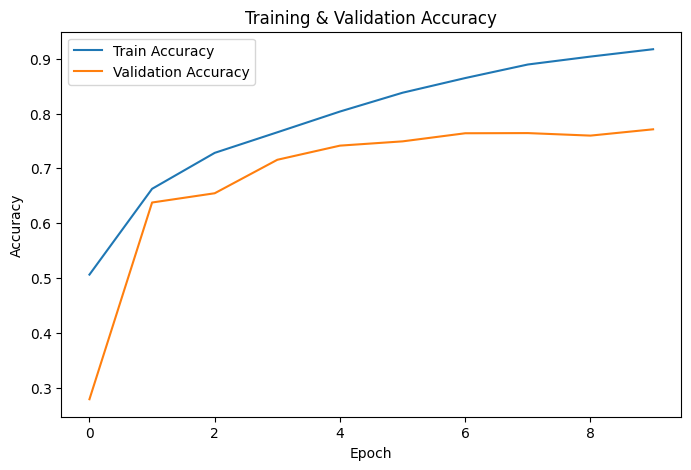

In [13]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy')
plt.legend()
plt.show()

In [14]:
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print("\nFinal Test Accuracy:", test_acc)


313/313 - 10s - 32ms/step - accuracy: 0.7713 - loss: 1.0065

Final Test Accuracy: 0.7713000178337097
